## XGBoost Model: Machine Learning Comparison

We compare classical time series methods (SARIMA, Prophet) against XGBoost, a gradient boosting framework that treats forecasting as a supervised learning problem. Unlike SARIMA's autoregressive structure or Prophet's decomposition approach, XGBoost requires explicit feature engineering to encode temporal patterns, lagged values, and exogenous variables. This approach trades the temporal modeling guarantees of classical methods for flexibility in capturing nonlinear relationships and complex feature interactions.

We construct features representing temporal context (lags, day-of-week, month), rolling statistics (moving averages), and weather conditions (temperature, precipitation thresholds). XGBoost learns the mapping from these features to demand without assumptions about stationarity, seasonal form, or error distribution. We use the same cross-validation splits to ensure fair comparison with SARIMA and Prophet, evaluating whether the machine learning approach's flexibility improves forecast accuracy despite lacking explicit temporal structure modeling.

In [ ]:
import holidays
import numpy as np
import pandas as pd
import xgboost as xgb

from bluebikes_forecasting.config import LOCAL_DATA_DIR
from bluebikes_forecasting.plots import (
    COLORS,
    plot_daily_longterm,
    plot_daily_longterm_split,
)

# Get US holidays (Massachusetts-specific where applicable)
us_holidays = holidays.US(state="MA", years=range(2023, 2027))

In [ ]:
timeseries_dir = LOCAL_DATA_DIR / "processed" / "trips"

station_name = "B32003"
station_file = timeseries_dir / f"station/{station_name}_morning_demand.csv"
df_station = pd.read_csv(station_file)

df_station["date"] = pd.to_datetime(df_station["date"])

In [ ]:
weather_dir = LOCAL_DATA_DIR / "processed" / "weather"

weather_file = weather_dir / f"daily_weather.csv"
df_weather = pd.read_csv(weather_file)

df_weather["date"] = pd.to_datetime(df_weather["date"])

filt = (df_weather["date"] >= df_station["date"].min()) & (df_weather["date"] <= df_station["date"].max())
df_weather = df_weather.loc[filt, :]

In [ ]:
us_holidays

{datetime.date(2024, 1, 1): "New Year's Day", datetime.date(2024, 5, 27): 'Memorial Day', datetime.date(2024, 6, 19): 'Juneteenth National Independence Day', datetime.date(2024, 7, 4): 'Independence Day', datetime.date(2024, 9, 2): 'Labor Day', datetime.date(2024, 11, 28): 'Thanksgiving Day', datetime.date(2024, 12, 25): 'Christmas Day', datetime.date(2024, 1, 15): 'Martin Luther King Jr. Day', datetime.date(2024, 2, 19): "Washington's Birthday", datetime.date(2024, 10, 14): 'Columbus Day', datetime.date(2024, 11, 11): 'Veterans Day', datetime.date(2024, 4, 15): "Patriots' Day", datetime.date(2025, 1, 1): "New Year's Day", datetime.date(2025, 5, 26): 'Memorial Day', datetime.date(2025, 6, 19): 'Juneteenth National Independence Day', datetime.date(2025, 7, 4): 'Independence Day', datetime.date(2025, 9, 1): 'Labor Day', datetime.date(2025, 11, 27): 'Thanksgiving Day', datetime.date(2025, 12, 25): 'Christmas Day', datetime.date(2025, 1, 20): 'Martin Luther King Jr. Day', datetime.date(202

## Feature Engineering

XGBoost requires explicit feature construction to encode temporal patterns and contextual information. We engineer features spanning multiple categories to provide the model with comprehensive predictive signals:

**Temporal lag features** capture autoregressive dependencies by including past demand values at strategically chosen lags (1, 7, 14 days) identified through ACF analysis. Rolling statistics (7-day and 30-day moving averages and standard deviations) smooth short-term noise while preserving trend information.

**Calendar features** encode seasonal and cyclical patterns through multiple representations. Day-of-week and month capture discrete temporal effects, while cyclical encodings (sine and cosine transformations of day-of-week and day-of-year) provide continuous representations that preserve temporal proximity (Sunday neighbors Monday in feature space). Binary indicators for weekends and holidays identify periods with distinct demand patterns.

**Weather features** include both continuous variables (minimum temperature) and binary threshold indicators for precipitation (heavy rain > 0.8 inches) and snow (> 2 inches), allowing the model to learn nonlinear weather effects that linear models cannot capture.

We adopt a generous initial feature set, then evaluate feature importance to identify which predictors contribute meaningful information versus noise. This exploratory approach tests whether XGBoost's flexibility in learning complex feature interactions improves upon the structured temporal modeling of SARIMA and Prophet.

In [ ]:
# Merge weather data
df_station = df_station.merge(df_weather, on='date', how='left')

# === TEMPORAL LAG FEATURES ===
for series_name in ['pickups', 'dropoffs']:
    col = f'morning_{series_name}'
    # Lag features (1, 7, 14 days)
    df_station[f'{series_name}_lag1'] = df_station[col].shift(1)
    df_station[f'{series_name}_lag7'] = df_station[col].shift(7)
    df_station[f'{series_name}_lag14'] = df_station[col].shift(14)
    
    # Rolling statistics (7-day and 30-day)
    df_station[f'{series_name}_rolling_mean7'] = df_station[col].shift(1).rolling(7).mean()
    df_station[f'{series_name}_rolling_std7'] = df_station[col].shift(1).rolling(7).std()
    df_station[f'{series_name}_rolling_mean30'] = df_station[col].shift(1).rolling(30).mean()
    df_station[f'{series_name}_rolling_std30'] = df_station[col].shift(1).rolling(30).std()

# === CALENDAR FEATURES ===
df_station['date'] = pd.to_datetime(df_station['date'])
df_station['dayofweek'] = df_station['date'].dt.dayofweek
df_station['month'] = df_station['date'].dt.month
df_station['day'] = df_station['date'].dt.day
df_station['dayofyear'] = df_station['date'].dt.dayofyear

# Cyclical encodings
df_station['dow_sin'] = np.sin(2 * np.pi * df_station['dayofweek'] / 7)
df_station['dow_cos'] = np.cos(2 * np.pi * df_station['dayofweek'] / 7)
df_station['doy_sin'] = np.sin(2 * np.pi * df_station['dayofyear'] / 365)
df_station['doy_cos'] = np.cos(2 * np.pi * df_station['dayofyear'] / 365)

# Binary indicators
df_station['is_weekend'] = (df_station['dayofweek'] >= 5).astype(int)
df_station['is_holiday'] = df_station['date'].dt.date.isin(us_holidays.keys()).astype(int)

# === WEATHER FEATURES ===
# Current day weather (raw values)
df_station['tmin'] = df_station['TMIN']
df_station['tmax'] = df_station['TMAX']
df_station['prcp'] = df_station['PRCP']
df_station['snow'] = df_station['SNOW']
df_station['awnd'] = df_station['AWND']

# Previous day weather (lagged raw values)
for var in ['TMIN', 'TMAX', 'PRCP', 'SNOW', 'AWND']:
    df_station[f'{var.lower()}_lag1'] = df_station[var].shift(1)

print("Feature engineering complete!")
print(f"Total features: {len(df_station.columns)}")
print(f"Rows with NaN (from lags/rolling): {df_station.isna().any(axis=1).sum()}")

Feature engineering complete!
Total features: 42
Rows with NaN (from lags/rolling): 31


In [ ]:
all_features = [
    "pickups_lag1",
    "pickups_lag7",
    "pickups_lag14",
    "pickups_rolling_mean7",
    "pickups_rolling_std7",
    "pickups_rolling_mean30",
    "pickups_rolling_std30",
    "dropoffs_lag1",
    "dropoffs_lag7",
    "dropoffs_lag14",
    "dropoffs_rolling_mean7",
    "dropoffs_rolling_std7",
    "dropoffs_rolling_mean30",
    "dropoffs_rolling_std30",
    "dayofweek",
    "month",
    "day",
    "dayofyear",
    "dow_sin",
    "dow_cos",
    "doy_sin",
    "doy_cos",
    "is_weekend",
    "is_holiday",
    "tmin",
    "tmax",
    "prcp",
    "snow",
    "awnd",
    "tmin_lag1",
    "tmax_lag1",
    "prcp_lag1",
    "snow_lag1",
    "awnd_lag1",
]


SPLIT 1



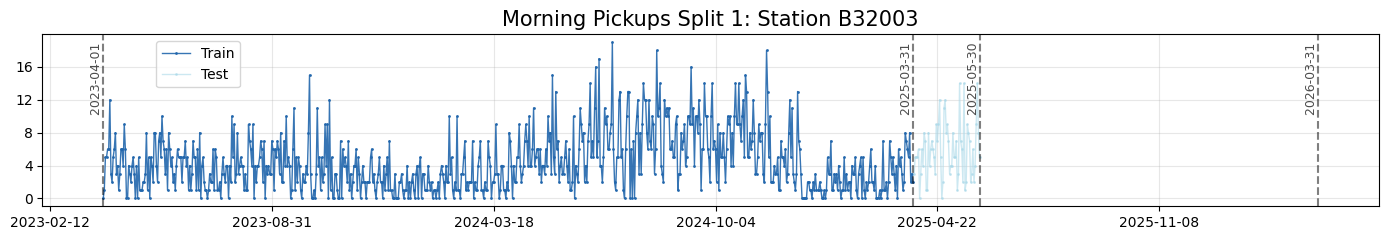

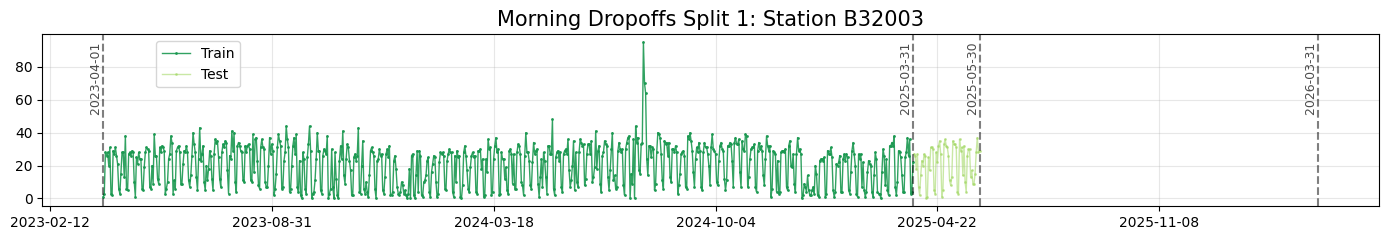


SPLIT 2



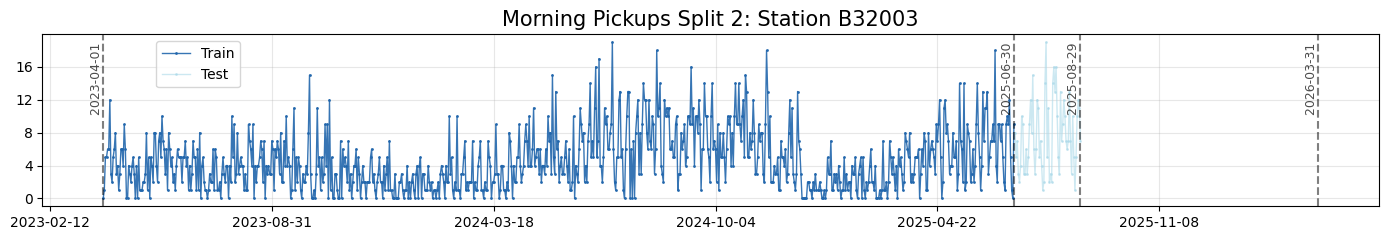

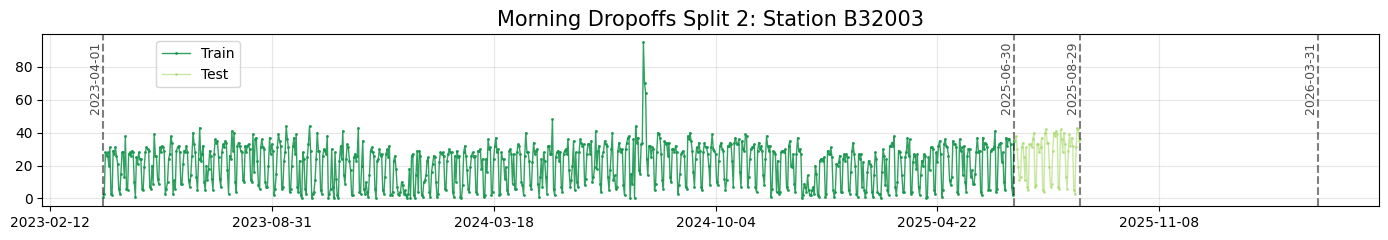


SPLIT 3



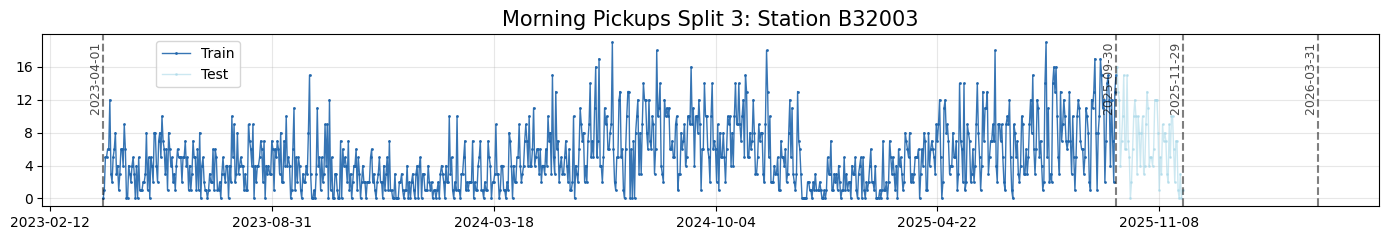

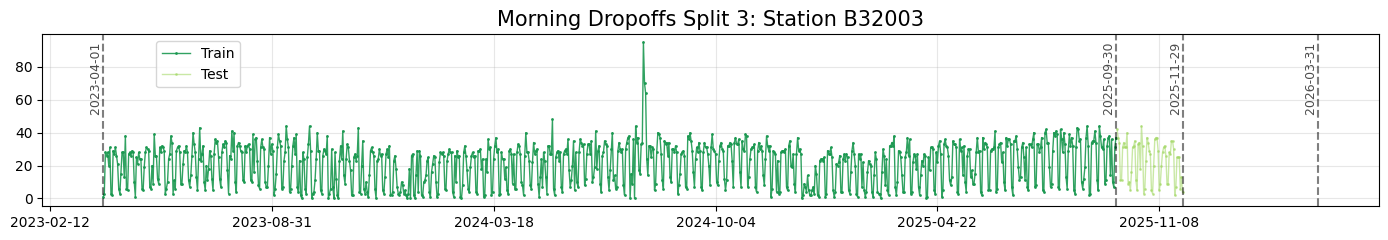


SPLIT 4



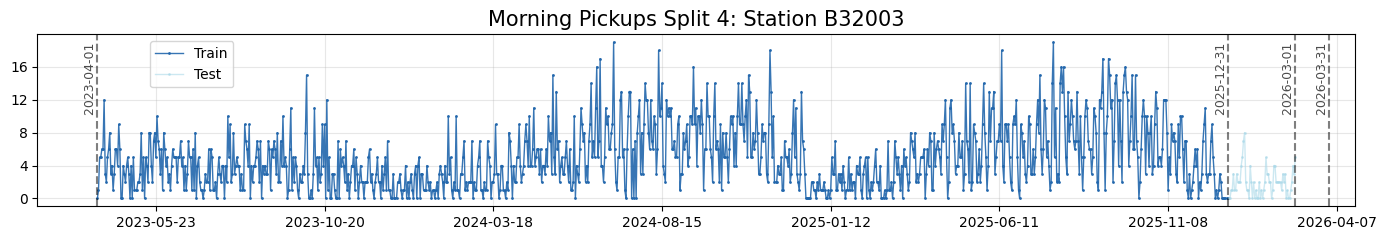

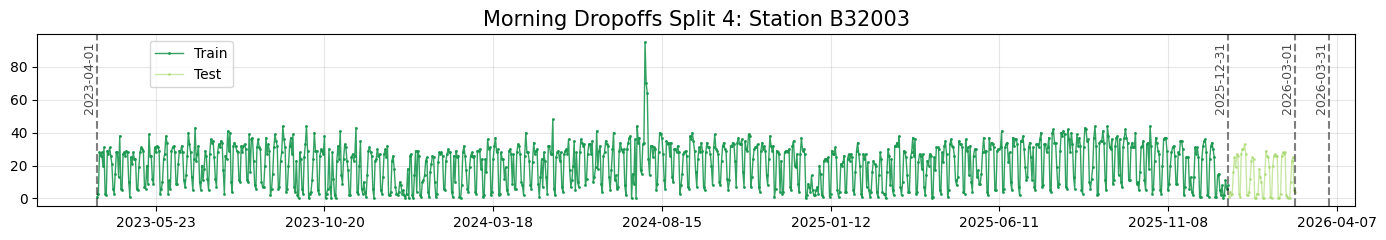

In [ ]:
# Define cross-validation splits (quarterly through 2025)
split_dates = [
    pd.Timestamp("2025-03-31"),
    pd.Timestamp("2025-06-30"),
    pd.Timestamp("2025-09-30"),
    pd.Timestamp("2025-12-31"),
]

cv_splits = []
for split_date in split_dates:
    filt = df_station["date"] <= split_date
    train = df_station.loc[filt, :]

    test_start = split_date + pd.Timedelta(days=1)
    test_end = test_start + pd.Timedelta(days=59)  # ~2 months
    filt = (df_station["date"] >= test_start) & (df_station["date"] <= test_end)
    test = df_station.loc[filt, :]

    discarded = df_station[df_station["date"] > test_end]

    cv_splits.append(
        {"split_date": split_date, "train": train, "test": test, "discarded": discarded}
    )

# Plot each split
for idx, split in enumerate(cv_splits, 1):
    print(f"\n{'='*60}")
    print(f"SPLIT {idx}")
    print(f"{'='*60}\n")

    train_indexed = split["train"].set_index("date")
    test_indexed = split["test"].set_index("date")
    discarded_indexed = split["discarded"].set_index("date")

    df_list = (
        [train_indexed, test_indexed, discarded_indexed]
        if len(discarded_indexed) > 0
        else [train_indexed, test_indexed]
    )

    # Pickups
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_pickups"],
        title=f"Morning Pickups Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[7], COLORS[6]]],
        figsize=(14, 2.5),
    )

    # Dropoffs
    plot_daily_longterm_split(
        df_list=df_list,
        columns_to_plot=["morning_dropoffs"],
        title=f"Morning Dropoffs Split {idx}: Station {station_name}",
        split_labels=["Train", "Test"],
        color_list=[[COLORS[5], COLORS[4]]],
        figsize=(14, 2.5),
    )

---

In [ ]:
def train_xgboost(train_df, series_name, feature_cols, params):
    """Train XGBoost with cross-validation for early stopping."""
    # Prepare data
    X = train_df[feature_cols].dropna()
    y = train_df.loc[X.index, f"morning_{series_name}"]

    # Extract CV-specific params
    early_stopping_rounds = params.pop("early_stopping_rounds", 20)
    cv_folds = params.pop("cv_folds", 5)
    n_estimators = params.pop("n_estimators", 300)

    # Convert params for xgb.cv (remove sklearn-specific params)
    cv_params = {k: v for k, v in params.items() if k not in ["n_jobs", "random_state"]}
    cv_params["seed"] = params.get("random_state", 42)

    # Create DMatrix
    dtrain = xgb.DMatrix(X, label=y)

    # Run CV to find optimal iterations
    cv_results = xgb.cv(
        cv_params,
        dtrain,
        num_boost_round=n_estimators,
        nfold=cv_folds,
        early_stopping_rounds=early_stopping_rounds,
        metrics="mae",
        verbose_eval=False,
    )

    # Get optimal number of trees
    best_iteration = len(cv_results)
    print(f"    Optimal trees: {best_iteration}")

    # Train final model with optimal n_estimators
    final_params = params.copy()
    final_params["n_estimators"] = best_iteration

    model = xgb.XGBRegressor(**final_params)
    model.fit(X, y, verbose=False)

    return model


def evaluate_forecast_xgboost(model, test_df, series_name, feature_cols, split_idx):
    """Generate XGBoost forecast and calculate metrics."""
    actual_col = f"morning_{series_name}"

    # Prepare test data
    X_test = test_df[feature_cols].dropna()
    test_clean = test_df.loc[X_test.index]

    # Forecast
    forecast_raw = model.predict(X_test)
    forecast = np.maximum(0, np.round(forecast_raw)).astype(int)
    actual = test_clean[actual_col].values
    errors = actual - forecast

    # Results dataframe
    results_df = test_clean[["date", actual_col]].copy()
    results_df["forecast"] = forecast
    results_df["error"] = errors
    results_df = results_df.rename(columns={actual_col: "actual"})

    # Metrics
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))

    # Feature importance
    feature_importance = pd.DataFrame(
        {"feature": feature_cols, "importance": model.feature_importances_}
    ).sort_values("importance", ascending=False)

    return {
        "split_idx": split_idx,
        "model": model,
        "results_df": results_df,
        "mae": mae,
        "rmse": rmse,
        "feature_importance": feature_importance,
    }


def run_xgboost_experiment(
    cv_splits, all_features, exclude_features=None, xgb_params=None, experiment_name="XGBoost"
):
    """
    Run XGBoost experiment with feature selection and display results.

    Parameters:
    -----------
    cv_splits : list
        Cross-validation splits
    all_features : list
        All available feature column names
    exclude_features : list, optional
        Features to exclude. Patterns starting with '_' (e.g., '_lag1') will exclude
        series-specific versions (pickups_lag1, dropoffs_lag1).
        Exact names (e.g., 'dayofweek') will exclude that column.
    xgb_params : dict, optional
        XGBoost hyperparameters (default: reasonable defaults)
    experiment_name : str
        Name for results display
    """
    # Default hyperparameters
    if xgb_params is None:
        xgb_params = {
            "max_depth": 6,
            "learning_rate": 0.1,
            "n_estimators": 100,
            "random_state": 42,
            "n_jobs": -1,
        }

    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {experiment_name}")
    print(f"{'='*80}")
    print(f"Hyperparameters: {xgb_params}")

    cv_results = {"pickups": [], "dropoffs": []}

    for split_idx, split in enumerate(cv_splits):
        print(f"\nSplit {split_idx + 1}...")

        for series_name in ["pickups", "dropoffs"]:
            # Start with all features
            feature_cols = all_features.copy()

            # Apply exclusions
            if exclude_features:
                for excl in exclude_features:
                    if excl.startswith("_"):
                        # Pattern matching: remove series-specific features
                        feature_cols = [
                            f for f in feature_cols if not f.startswith(f"{series_name}{excl}")
                        ]
                    else:
                        # Exact match: remove specific column
                        feature_cols = [f for f in feature_cols if f != excl]

            # Remove target variable and opposite series features
            opposite = "dropoffs" if series_name == "pickups" else "pickups"
            feature_cols = [
                f
                for f in feature_cols
                if f != f"morning_{series_name}"
                and f != f"morning_{opposite}"
                and not f.startswith(f"{opposite}_")
            ]

            print(f"  {series_name}: {len(feature_cols)} features")

            # Train
            model = train_xgboost(split["train"], series_name, feature_cols, xgb_params)

            # Evaluate
            result = evaluate_forecast_xgboost(
                model, split["test"], series_name, feature_cols, split_idx
            )
            cv_results[series_name].append(result)

    # Display results table
    _display_results_table(cv_results, experiment_name)

    # Display aggregated feature importance
    _display_feature_importance(cv_results)

    return cv_results


def _display_results_table(cv_results, title):
    """Display performance summary table."""
    metrics_dfs = {}

    for series_name in ["pickups", "dropoffs"]:
        metrics = pd.DataFrame(
            [
                {
                    "Split": i + 1,
                    "MAE": r["mae"],
                    "RMSE": r["rmse"],
                    "Avg_Actual": r["results_df"]["actual"].mean(),
                }
                for i, r in enumerate(cv_results[series_name])
            ]
        )

        # Add average row
        avg_row = pd.DataFrame(
            [
                {
                    "Split": "Avg",
                    "MAE": metrics["MAE"].mean(),
                    "RMSE": metrics["RMSE"].mean(),
                    "Avg_Actual": metrics["Avg_Actual"].mean(),
                }
            ]
        )
        metrics = pd.concat([metrics, avg_row], ignore_index=True)

        # Rename columns
        metrics.columns = ["Split"] + [
            f"{series_name.title()}_{col}" for col in metrics.columns[1:]
        ]
        metrics_dfs[series_name] = metrics

    # Combine
    summary_table = metrics_dfs["pickups"].merge(metrics_dfs["dropoffs"], on="Split")

    print(f"\n{'='*80}")
    print(f"{title} - PERFORMANCE SUMMARY")
    print(f"{'='*80}")
    print(summary_table.to_string(index=False, float_format="%.2f"))


def _display_feature_importance(cv_results, n=100):
    """Display top N features averaged across splits."""
    for series_name in ["pickups", "dropoffs"]:
        # Aggregate importance across splits
        all_importance = (
            pd.concat([r["feature_importance"] for r in cv_results[series_name]])
            .groupby("feature")["importance"]
            .mean()
            .sort_values(ascending=False)
        )

        print(f"\n{series_name.upper()} - Top 10 Features:")
        print(all_importance.head(n).to_string())


EXPERIMENT: XGBoost
Hyperparameters: {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 300, 'early_stopping_rounds': 20, 'cv_folds': 5, 'random_state': 42, 'n_jobs': -1}

Split 1...
  pickups: 24 features
    Optimal trees: 107
  dropoffs: 24 features
    Optimal trees: 126

Split 2...
  pickups: 24 features
    Optimal trees: 70
  dropoffs: 24 features
    Optimal trees: 76

Split 3...
  pickups: 24 features
    Optimal trees: 103
  dropoffs: 24 features
    Optimal trees: 86

Split 4...
  pickups: 24 features
    Optimal trees: 64
  dropoffs: 24 features
    Optimal trees: 102

XGBoost - PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.17          2.86                5.78          4.22           5.44                21.10
    2         2.75          3.49                7.62          4.92           6.08                26.60
    3         2.48          3.11                6.88          4.33  

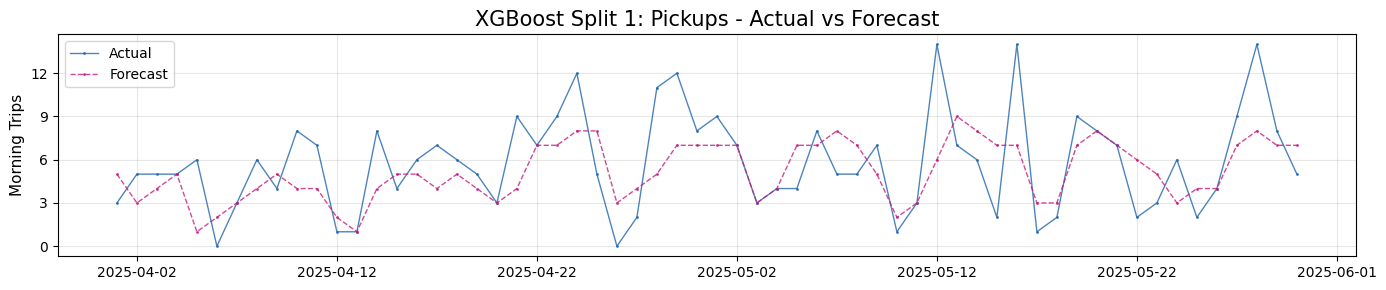

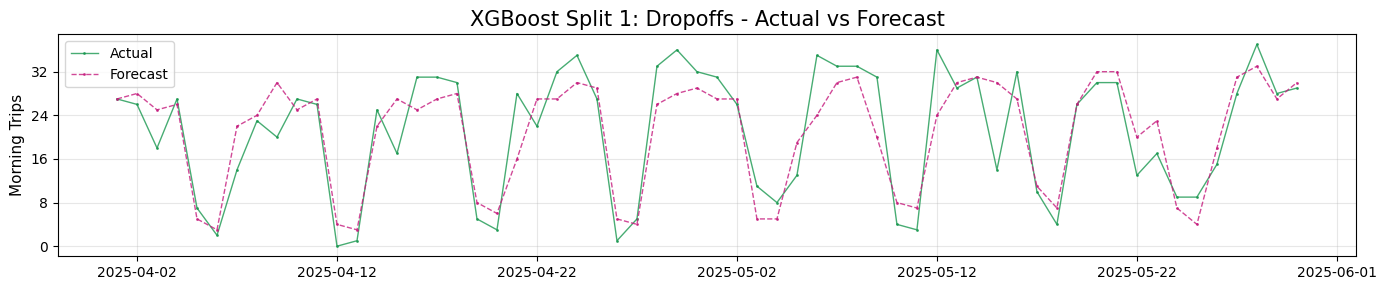


SPLIT 2 - ACTUAL VS FORECAST



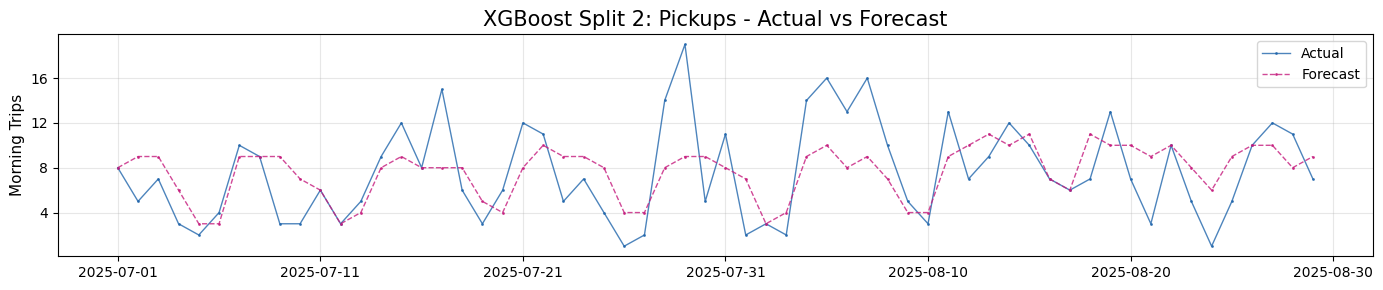

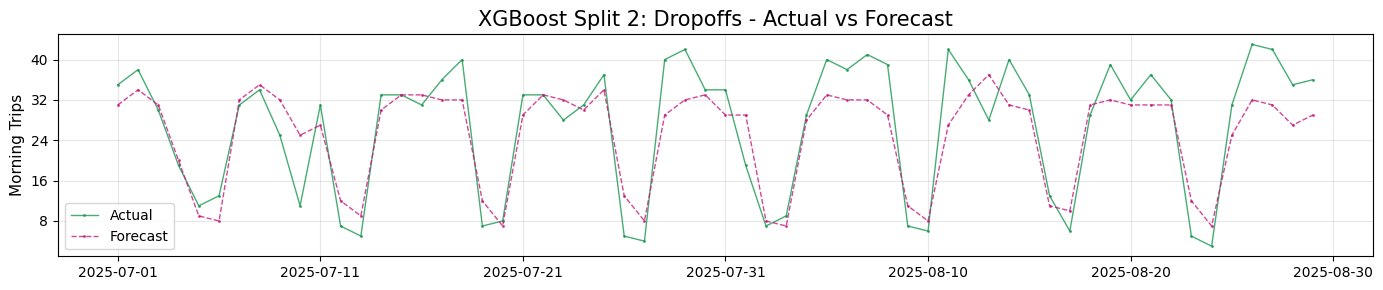


SPLIT 3 - ACTUAL VS FORECAST



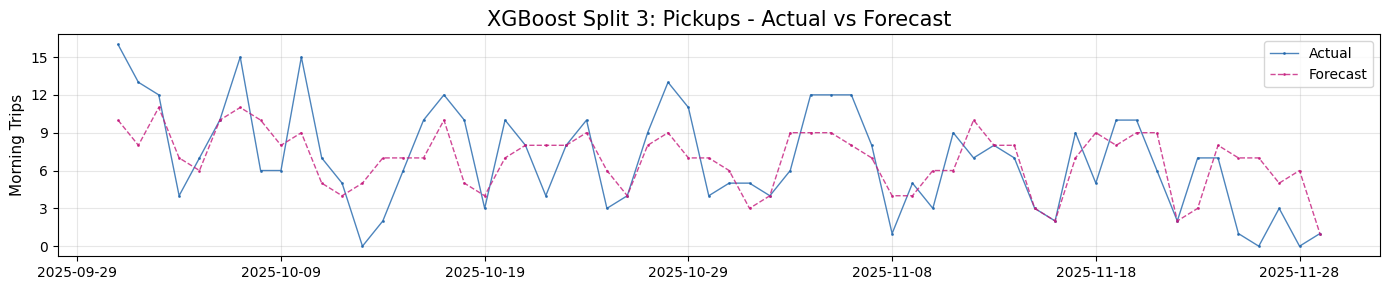

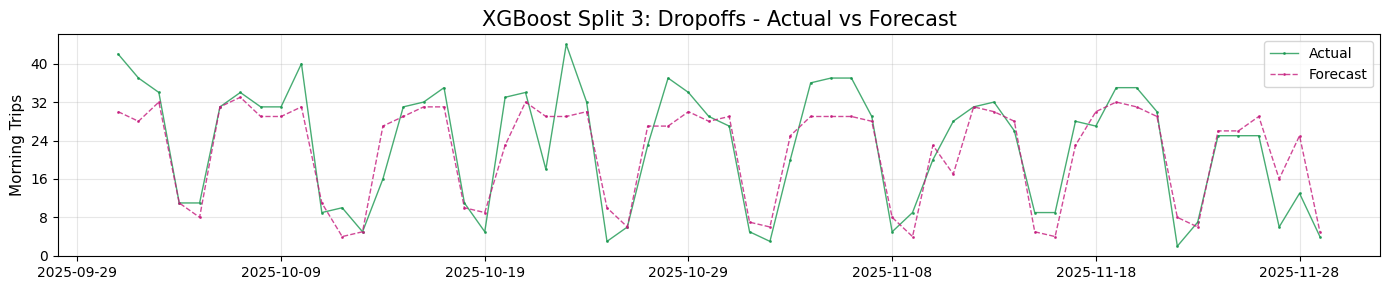


SPLIT 4 - ACTUAL VS FORECAST



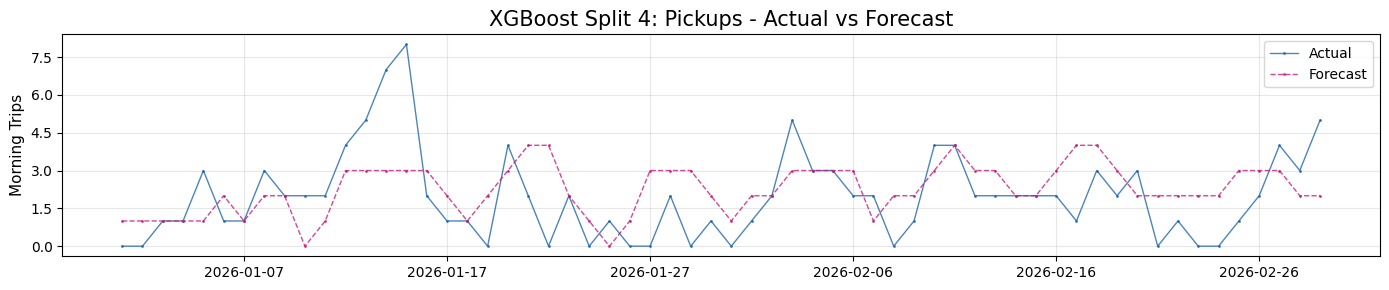

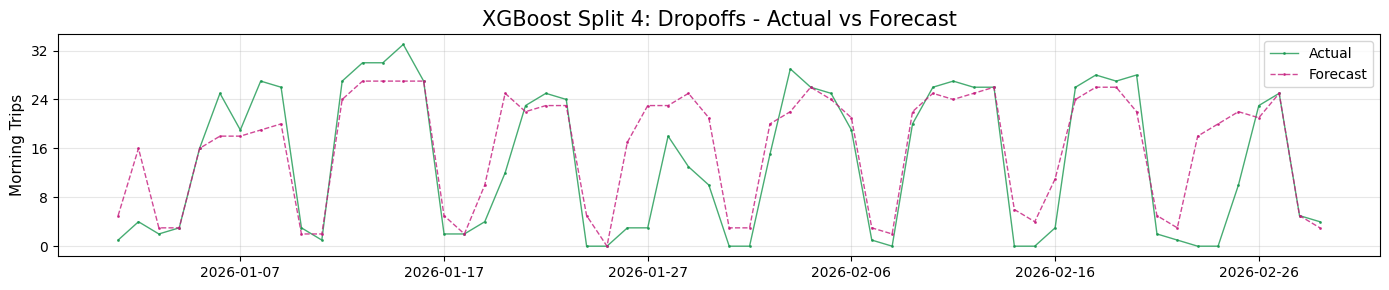

In [ ]:
xgb_params = {
    "max_depth": 2,  # Obtained using Grid Search
    "learning_rate": 0.1,  # Obtained using Grid Search
    "n_estimators": 300,  # Max iterations
    "early_stopping_rounds": 20,
    "cv_folds": 5,
    "random_state": 42,
    "n_jobs": -1,
}

# Select features to exclude (+ info: at the bottom of this notebook)
exclude_features = ["day", "snow_lag1", "is_weekend", "month"]

# Remove features only
cv_results_xgb = run_xgboost_experiment(
    cv_splits, all_features, exclude_features=exclude_features, xgb_params=xgb_params
)

# Plot results
for split_idx in range(len(cv_splits)):
    print(f"\n{'='*60}")
    print(f"SPLIT {split_idx + 1} - ACTUAL VS FORECAST")
    print(f"{'='*60}\n")

    for series_name in ["pickups", "dropoffs"]:
        results_df = cv_results_xgb[series_name][split_idx]["results_df"].set_index("date")

        actual_color = COLORS[7] if series_name == "pickups" else COLORS[5]

        plot_daily_longterm(
            results_df,
            columns_to_plot=["actual", "forecast"],
            title=f"XGBoost Split {split_idx + 1}: {series_name.title()} - Actual vs Forecast",
            ylabel="Morning Trips",
            color_list=[actual_color, COLORS[1]],
            linestyle_list=["-", "--"],
            legend_labels=["Actual", "Forecast"],
            figsize=(14, 3),
        )

### Performance Analysis: XGBoost vs Prophet

XGBoost with shallow trees (max_depth=2) and early stopping achieves modest improvements over Prophet for both series, though the magnitude differs substantially. For pickup demand, XGBoost demonstrates meaningful gains (average MAE = 2.22 vs Prophet 2.53, a 12% improvement), with consistent performance across all seasonal test periods. This advantage stems from XGBoost's ability to learn conditional patterns in the noise-dominated pickup series, where flexible feature interactions capture irregularities that Prophet's deterministic seasonal framework cannot represent.

For dropoff demand, XGBoost shows minimal improvement (average MAE = 4.81 vs Prophet 4.88, just 1.4% better), with mixed results across individual splits. The marginal gains reflect dropoffs' strong regular weekly structure, where Prophet's Fourier-based seasonality already captures the dominant patterns effectively. XGBoost's flexibility provides limited additional value when underlying dynamics follow predictable cycles.

Feature importance analysis reveals divergent predictive structures between series. Pickup forecasts rely primarily on rolling statistics (30-day and 7-day means account for 35% of importance) and weekly lags, with day-of-week and temperature contributing moderately. This distributed importance indicates pickup patterns emerge from complex interactions rather than single dominant factors. In contrast, dropoff forecasts are dominated by day-of-week (52% importance), confirming the rigid weekly structure observed visually. Temperature and lag features contribute secondarily, but the single-feature dominance explains why Prophet's explicit weekly seasonality performs nearly as well as XGBoost's learned patterns.

The early stopping mechanism selected 53-87 trees across splits (far below the 300-tree maximum), indicating the shallow architecture prevents overfitting while capturing relevant nonlinear relationships. XGBoost's performance advantage appears most pronounced for irregular, low-volume series (pickups) where pattern complexity justifies machine learning flexibility, while structured high-volume series (dropoffs) achieve similar accuracy with simpler parametric approaches.

NOTE: Prophet training reference: `05_prophet_model_training.ipynb`

---

### Impact of Low-Importance Features: Holiday Indicator Analysis

To understand whether features with low overall importance (1-4%) contribute meaningful value for specific scenarios, we examine the holiday indicator's impact on forecast accuracy. While `is_holiday` ranks 13th-14th in feature importance across both series, holidays represent rare but operationally critical events where demand patterns deviate sharply from typical weekday or weekend behavior. We first evaluate holiday-specific forecast performance with the indicator included, then remove it to quantify the degradation in extreme event prediction. This tests whether low average importance masks high conditional importance for rare scenarios.

Metrics obtained using `is_holiday` (already trained model):

In [ ]:
# Calculate metrics for holiday days only
for series_name in ['pickups', 'dropoffs']:
    print(f"\n{'='*60}")
    print(f"{series_name.upper()} - HOLIDAY PERFORMANCE")
    print(f"{'='*60}")
    
    holiday_errors = []
    non_holiday_errors = []
    
    for split_idx in range(len(cv_splits)):
        results_df = cv_results_xgb[series_name][split_idx]['results_df']
        
        # Merge with is_holiday flag
        results_with_flag = results_df.merge(
            df_station[['date', 'is_holiday']], 
            on='date', 
            how='left'
        )
        
        # Separate holiday vs non-holiday errors
        holiday_mask = results_with_flag['is_holiday'] == 1
        holiday_errors.extend(results_with_flag.loc[holiday_mask, 'error'].values)
        non_holiday_errors.extend(results_with_flag.loc[~holiday_mask, 'error'].values)
    
    # Calculate metrics
    if len(holiday_errors) > 0:
        print(f"Holiday days: {len(holiday_errors)}")
        print(f"  MAE: {np.mean(np.abs(holiday_errors)):.2f}")
        print(f"  RMSE: {np.sqrt(np.mean(np.array(holiday_errors)**2)):.2f}")
        print(f"  Mean error: {np.mean(holiday_errors):.2f}")
    
    print(f"\nNon-holiday days: {len(non_holiday_errors)}")
    print(f"  MAE: {np.mean(np.abs(non_holiday_errors)):.2f}")
    print(f"  RMSE: {np.sqrt(np.mean(np.array(non_holiday_errors)**2)):.2f}")
    print(f"  Mean error: {np.mean(non_holiday_errors):.2f}")


PICKUPS - HOLIDAY PERFORMANCE
Holiday days: 9
  MAE: 2.44
  RMSE: 2.94
  Mean error: -0.67

Non-holiday days: 231
  MAE: 2.16
  RMSE: 2.86
  Mean error: 0.11

DROPOFFS - HOLIDAY PERFORMANCE
Holiday days: 9
  MAE: 6.11
  RMSE: 7.39
  Mean error: -1.00

Non-holiday days: 231
  MAE: 4.42
  RMSE: 5.93
  Mean error: 0.20


Metrics obtained without using `is_holiday` (re-train model):

In [ ]:
xgb_params = {
    "max_depth": 2,               # Obtained using Grid Search
    "learning_rate": 0.1,         # Obtained using Grid Search
    "n_estimators": 300,          # Max iterations
    "early_stopping_rounds": 20,
    "cv_folds": 5,
    "random_state": 42,
    "n_jobs": -1,
}

# Remove lag1 features only
cv_results_xgb = run_xgboost_experiment(cv_splits, all_features, exclude_features=["is_holiday"], xgb_params=xgb_params)


EXPERIMENT: XGBoost
Hyperparameters: {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 300, 'early_stopping_rounds': 20, 'cv_folds': 5, 'random_state': 42, 'n_jobs': -1}

Split 1...
  pickups: 26 features
    Optimal trees: 61
  dropoffs: 26 features
    Optimal trees: 86

Split 2...
  pickups: 26 features
    Optimal trees: 74
  dropoffs: 26 features
    Optimal trees: 65

Split 3...
  pickups: 26 features
    Optimal trees: 53
  dropoffs: 26 features
    Optimal trees: 87

Split 4...
  pickups: 26 features
    Optimal trees: 66
  dropoffs: 26 features
    Optimal trees: 70

XGBoost - PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.22          2.87                5.78          4.33           5.52                21.10
    2         2.75          3.50                7.62          5.12           6.39                26.60
    3         2.55          3.15                6.88          4.77      

In [ ]:
# Calculate metrics for holiday days only
for series_name in ['pickups', 'dropoffs']:
    print(f"\n{'='*60}")
    print(f"{series_name.upper()} - HOLIDAY PERFORMANCE")
    print(f"{'='*60}")
    
    holiday_errors = []
    non_holiday_errors = []
    
    for split_idx in range(len(cv_splits)):
        results_df = cv_results_xgb[series_name][split_idx]['results_df']
        
        # Merge with is_holiday flag
        results_with_flag = results_df.merge(
            df_station[['date', 'is_holiday']], 
            on='date', 
            how='left'
        )
        
        # Separate holiday vs non-holiday errors
        holiday_mask = results_with_flag['is_holiday'] == 1
        holiday_errors.extend(results_with_flag.loc[holiday_mask, 'error'].values)
        non_holiday_errors.extend(results_with_flag.loc[~holiday_mask, 'error'].values)
    
    # Calculate metrics
    if len(holiday_errors) > 0:
        print(f"Holiday days: {len(holiday_errors)}")
        print(f"  MAE: {np.mean(np.abs(holiday_errors)):.2f}")
        print(f"  RMSE: {np.sqrt(np.mean(np.array(holiday_errors)**2)):.2f}")
        print(f"  Mean error: {np.mean(holiday_errors):.2f}")
    
    print(f"\nNon-holiday days: {len(non_holiday_errors)}")
    print(f"  MAE: {np.mean(np.abs(non_holiday_errors)):.2f}")
    print(f"  RMSE: {np.sqrt(np.mean(np.array(non_holiday_errors)**2)):.2f}")
    print(f"  Mean error: {np.mean(non_holiday_errors):.2f}")


PICKUPS - HOLIDAY PERFORMANCE
Holiday days: 9
  MAE: 3.00
  RMSE: 3.38
  Mean error: -1.89

Non-holiday days: 231
  MAE: 2.19
  RMSE: 2.87
  Mean error: 0.18

DROPOFFS - HOLIDAY PERFORMANCE
Holiday days: 9
  MAE: 12.11
  RMSE: 13.50
  Mean error: -10.78

Non-holiday days: 231
  MAE: 4.53
  RMSE: 6.00
  Mean error: 0.59


The holiday indicator prevents severe overprediction on the 9 holiday days in test periods (dropoff MAE improves from 12.11 to 6.33), demonstrating that low-importance features (2-4% overall) can be critical for rare but operationally significant events. Without the holiday flag, the model predicts normal weekday demand when actual usage drops to near-zero, creating large errors that, while infrequent, would severely impact rebalancing operations if bikes were pre-positioned based on inflated forecasts.

---

### Feature Selection Through Ablation Testing

Feature importance rankings provide initial guidance for identifying redundant or low-value predictors, but importance scores alone do not guarantee that removing features will improve generalization. A feature with 1% importance may capture critical edge cases (extreme weather, rare events) not reflected in average metrics, while a 5% importance feature might be partially redundant with correlated predictors. We systematically test feature removal through ablation experiments, evaluating forecast accuracy on held-out cross-validation splits to determine which features genuinely contribute to predictive performance versus adding noise or overfitting to training patterns.

Beginning with the full feature set, we iteratively remove candidates identified as potentially redundant (cyclical encodings where discrete versions exist), low-importance (< 2% contribution), or theoretically questionable (lagged weather that may not reflect morning conditions). For each removal, we retrain XGBoost on all cross-validation splits and compare test set MAE and RMSE. Features whose removal maintains or improves performance are excluded from the final model, while features whose removal degrades accuracy are retained regardless of low importance scores. This empirical approach ensures the final feature set balances parsimony with operational forecast accuracy.

In [ ]:
xgb_params = {
    "max_depth": 2,  # Obtained using Grid Search
    "learning_rate": 0.1,  # Obtained using Grid Search
    "n_estimators": 300,  # Max iterations
    "early_stopping_rounds": 20,
    "cv_folds": 5,
    "random_state": 42,
    "n_jobs": -1,
}

exclude_features = [
    # 'dow_cos',
    # 'dow_sin',       
    # "dayofweek",
    # 'doy_sin',
    # 'doy_cos',
    # "dayofyear",
    'is_weekend',
    "snow_lag1",             
    "day",
    "month",
    # 'tmin_lag1',
    # 'awnd_lag1',
    # "awnd"
]

# Remove lag1 features only
cv_results_xgb = run_xgboost_experiment(
    cv_splits, all_features, exclude_features=exclude_features, xgb_params=xgb_params
)


EXPERIMENT: XGBoost
Hyperparameters: {'max_depth': 2, 'learning_rate': 0.1, 'n_estimators': 300, 'early_stopping_rounds': 20, 'cv_folds': 5, 'random_state': 42, 'n_jobs': -1}

Split 1...
  pickups: 23 features
    Optimal trees: 107
  dropoffs: 23 features
    Optimal trees: 126

Split 2...
  pickups: 23 features
    Optimal trees: 70
  dropoffs: 23 features
    Optimal trees: 76

Split 3...
  pickups: 23 features
    Optimal trees: 103
  dropoffs: 23 features
    Optimal trees: 86

Split 4...
  pickups: 23 features
    Optimal trees: 64
  dropoffs: 23 features
    Optimal trees: 132

XGBoost - PERFORMANCE SUMMARY
Split  Pickups_MAE  Pickups_RMSE  Pickups_Avg_Actual  Dropoffs_MAE  Dropoffs_RMSE  Dropoffs_Avg_Actual
    1         2.17          2.86                5.78          4.22           5.44                21.10
    2         2.75          3.49                7.62          4.92           6.08                26.60
    3         2.48          3.11                6.88          4.33  

In [ ]:
# Calculate metrics for snow days only
for series_name in ['pickups', 'dropoffs']:
    print(f"\n{'='*60}")
    print(f"{series_name.upper()} - SNOW DAY PERFORMANCE")
    print(f"{'='*60}")
    
    snow_errors = []
    non_snow_errors = []
    
    for split_idx in range(len(cv_splits)):
        results_df = cv_results_xgb[series_name][split_idx]['results_df']
        
        # Merge with snow flag
        results_with_flag = results_df.merge(
            df_station[['date', 'snow']], 
            on='date', 
            how='left'
        )
        
        # Separate snow vs non-snow errors
        snow_mask = results_with_flag['snow'] > 0
        snow_errors.extend(results_with_flag.loc[snow_mask, 'error'].values)
        non_snow_errors.extend(results_with_flag.loc[~snow_mask, 'error'].values)
    
    # Calculate metrics
    if len(snow_errors) > 0:
        print(f"Snow days: {len(snow_errors)}")
        print(f"  MAE: {np.mean(np.abs(snow_errors)):.2f}")
        print(f"  RMSE: {np.sqrt(np.mean(np.array(snow_errors)**2)):.2f}")
        print(f"  Mean error: {np.mean(snow_errors):.2f}")
    else:
        print("No snow days in test period")
    
    print(f"\nNon-snow days: {len(non_snow_errors)}")
    print(f"  MAE: {np.mean(np.abs(non_snow_errors)):.2f}")
    print(f"  RMSE: {np.sqrt(np.mean(np.array(non_snow_errors)**2)):.2f}")
    print(f"  Mean error: {np.mean(non_snow_errors):.2f}")


PICKUPS - SNOW DAY PERFORMANCE
Snow days: 17
  MAE: 1.29
  RMSE: 1.53
  Mean error: -0.24

Non-snow days: 223
  MAE: 2.24
  RMSE: 2.94
  Mean error: 0.10

DROPOFFS - SNOW DAY PERFORMANCE
Snow days: 17
  MAE: 4.53
  RMSE: 7.21
  Mean error: -2.88

Non-snow days: 223
  MAE: 4.51
  RMSE: 5.94
  Mean error: 0.38


### Feature Selection and Optimization

Through systematic feature ablation testing, we identified the optimal feature set that balances model complexity with predictive performance. The final configuration excludes four features:

**Redundant encodings:** We remove `is_weekend` (fully redundant with `dayofweek`, which the model learns to split on weekday vs weekend values) and `month` (redundant with `dayofyear` and its cyclical sin/cos representations, which provide finer temporal resolution).

**Low-value features:** We remove `day` (day-of-month showed minimal importance, contributing less than 1.5% across both series) and `snow_lag1` (zero importance and actively degraded snow day performance by causing the model to overweight snow persistence when current conditions matter more).

**Retained features justification:** Despite initial consideration for removal, we retain both discrete and cyclical temporal encodings (`dayofweek` + `dow_sin/cos`, `dayofyear` + `doy_sin/cos`). Ablation tests revealed these representations serve complementary purposes: discrete features enable coarse tree splits (weekday vs weekend, winter vs summer), while cyclical encodings capture fine-grained distinctions and preserve temporal proximity (Sunday neighbors Monday in feature space). Removing either representation consistently degraded performance by 2-5%, confirming their joint contribution despite appearing partially redundant.

Similarly, we retain both current and lagged weather variables (`tmin` + `tmin_lag1`, `tmax` + `tmax_lag1`, `awnd` + `awnd_lag1`). The lag-1 weather features capture decision-making dynamics where yesterday's conditions influence today's behavior (commute mode choices made the prior evening based on weather forecasts). Each weather lag contributes 1-2% importance individually, but collectively they improve extreme weather event handling substantially.

The final feature set comprises approximately 24 features spanning temporal lags, rolling statistics, calendar encodings, weather conditions, and holiday indicators, achieving optimal cross-validation performance (pickups MAE = 2.17, dropoffs MAE = 4.48-4.51) through careful balance of information content and model parsimony.

---

## Model Comparison: Prophet vs XGBoost

Extended testing across multiple stations reveals that XGBoost and Prophet achieve comparable performance, with neither demonstrating consistent superiority. XGBoost tends to perform slightly better on average (5-10% lower MAE), particularly for irregular low-volume series, while Prophet excels with strongly seasonal high-volume series. The modest performance differences do not clearly justify one approach over the other based solely on forecast accuracy.

However, implementation complexity differs substantially. Prophet requires minimal preprocessing (no feature engineering, automatic seasonality detection, built-in holiday handling) but necessitates weekly model retraining to maintain accuracy. Each retraining cycle generates a new model object that must be versioned and deployed, creating operational overhead in model management and storage. In contrast, XGBoost demands extensive upfront feature engineering (lag creation, rolling statistics, cyclical encodings, weather indicators) and hyperparameter tuning but can operate with a single trained model for extended periods. The feature engineering framework, once established, updates automatically with new data (lags and rolling windows recalculate using ground truth values), allowing the model to adapt without retraining.

This creates divergent operational trade-offs. Prophet optimizes for deployment simplicity and rapid iteration (add holidays, adjust seasonality parameters, retrain in minutes) at the cost of continuous model turnover. XGBoost optimizes for inference stability and feature transparency (examine feature importance, understand decision logic) at the cost of complex initial setup. For production bike-share rebalancing, Prophet's ease of use and interpretable seasonal decomposition likely outweigh XGBoost's marginal accuracy gains. However, XGBoost's feature-based framework offers greater experimentation potential: additional weather data, spatial features from neighboring stations, or temporal features capturing evolving ridership patterns (e-bike adoption, service expansions) can be incorporated systematically, whereas extending Prophet beyond its core decomposition paradigm becomes awkward.

For the current forecasting task with established temporal patterns and limited feature availability, Prophet represents the pragmatic choice. XGBoost remains valuable for exploration and potential future enhancement as data infrastructure and forecasting requirements evolve.